In this tutorial, we will predict digits.
Let's start

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Any results you write to the current directory are saved as output.

/kaggle/input/digit-recognizer/sample_submission.csv
/kaggle/input/digit-recognizer/test.csv
/kaggle/input/digit-recognizer/train.csv


In [2]:
train = pd.read_csv('/kaggle/input/digit-recognizer/train.csv')
x_test = pd.read_csv('/kaggle/input/digit-recognizer/test.csv')                    


In [3]:
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2
from collections import deque
import numpy as np

In [4]:
y_train = train['label']
x_train = train.drop(labels = ['label'], axis=1)

In [5]:
x_train.shape


(42000, 784)

In [6]:
image_index = 7777
print(y_train[image_index])

5


In [7]:
# Reshaping the array to 4-dims so that it can work with the Keras API
x_train = x_train.values.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.values.reshape(x_test.shape[0], 28, 28, 1)

In [8]:
print(x_train.shape)

(42000, 28, 28, 1)


In [9]:
input_shape = (28, 28, 1)


In [10]:
# Making sure that the values are float so that we can get decimal points after division
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

In [11]:
# Normalizing the RGB codes by dividing it to the max RGB value.
x_train /= 255
x_test /= 255


In [12]:
print('x_train shape:', x_train.shape)
print('Number of images in x_train', x_train.shape[0])
print('Number of images in x_test', x_test.shape[0])

x_train shape: (42000, 28, 28, 1)
Number of images in x_train 42000
Number of images in x_test 28000


AxesImage(54,36;334.8x217.44)


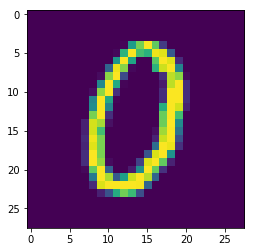

In [13]:
# Some examples
print(plt.imshow(x_train[5][:,:,0]))

AxesImage(54,36;334.8x217.44)


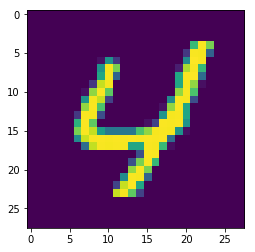

In [14]:
print(plt.imshow(x_train[450][:,:,0]))

AxesImage(54,36;334.8x217.44)


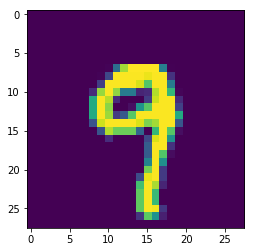

In [15]:
print(plt.imshow(x_train[4215][:,:,0]))

# CNN
 Okay let's explain what CNN is.
 
 In neural networks, Convolutional neural network (ConvNets or CNNs) is one of the main categories to do images recognition, images classifications. Objects detections, recognition faces etc., are some of the areas where CNNs are widely used.

CNN image classifications takes an input image, process it and classify it under certain categories (Eg., Dog, Cat, Tiger, Lion). Computers sees an input image as array of pixels and it depends on the image resolution. Based on the image resolution, it will see h x w x d( h = Height, w = Width, d = Dimension ). Eg., An image of 6 x 6 x 3 array of matrix of RGB (3 refers to RGB values) and an image of 4 x 4 x 1 array of matrix of grayscale image.

Technically, deep learning CNN models to train and test, each input image will pass it through a series of convolution layers with filters (Kernals), Pooling, fully connected layers (FC) and apply Softmax function to classify an object with probabilistic values between 0 and 1. The below figure is a complete flow of CNN to process an input image and classifies the objects based on values.

In [16]:
# Importing the required Keras modules containing model and layers
from keras.models import Sequential
from keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D

Using TensorFlow backend.


In [17]:
# Creating a Sequential Model and adding the layers
model = Sequential()
model.add(Conv2D(256, kernel_size=(5, 5), activation='relu', input_shape=input_shape))
model.add(Conv2D(128, kernel_size=(5, 5), activation='relu'))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())  # Flattening the 2D arrays for fully connected layers
model.add(Dense(100, activation=tf.nn.relu))
model.add(Dropout(0.2))
model.add(Dense(10, activation=tf.nn.softmax))

In [18]:
#compiling the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [19]:
model.fit(x=x_train,y=y_train,epochs=150, verbose = 1)

Epoch 1/150
42000/42000 [==============================] - 16s 382us/step - loss: 0.1446 - accuracy: 0.9550
Epoch 2/150
42000/42000 [==============================] - 12s 275us/step - loss: 0.0574 - accuracy: 0.9826
Epoch 3/150
42000/42000 [==============================] - 12s 277us/step - loss: 0.0398 - accuracy: 0.9877
Epoch 4/150
42000/42000 [==============================] - 11s 273us/step - loss: 0.0298 - accuracy: 0.9910
Epoch 5/150
42000/42000 [==============================] - 12s 275us/step - loss: 0.0260 - accuracy: 0.9922
Epoch 6/150
42000/42000 [==============================] - 12s 288us/step - loss: 0.0202 - accuracy: 0.9937
Epoch 7/150
42000/42000 [==============================] - 12s 277us/step - loss: 0.0158 - accuracy: 0.9950
Epoch 8/150
42000/42000 [==============================] - 12s 276us/step - loss: 0.0165 - accuracy: 0.9950
Epoch 9/150
42000/42000 [==============================] - 12s 276us/step - loss: 0.0118 - accuracy: 0.9961
Epoch 10/150
42000/42000 [==

In [20]:
pred = model.predict(x_test)
results = np.argmax(pred,axis = 1)
results = pd.Series(results,name = 'Label')

In [21]:
sub = pd.concat([pd.Series(range(1,28001),name = "ImageId"),results],axis = 1)

sub.to_csv("cnn_best_model.csv",index=False)

If you like it, please vote! :)